# Project Analysis: Netflix Content Popularity

**Course:** CMSE 202  
**Completed Project Notebook**

**Group Members:**  
- Jaehan Kim — kimjaeha@msu.edu  
- Akshita Mylavarapu — mylavar2@msu.edu  
- Taliah Blom — blomtali@msu.edu  
- Ahmed Chishti — chishti2@msu.edu  

## Main Research Question

Can Netflix content features such as release year, rating, duration, genre, country, and content type help explain or predict popularity?

## Popularity Definition

In this project, popularity will mainly be measured using available popularity-related variables from the datasets, especially TMDB popularity, IMDb votes, IMDb score, and TMDB score.

## Dataset Sources

1. `titles.csv`  
2. `credits.csv`  

Source: https://www.kaggle.com/datasets/victorsoeiro/netflix-tv-shows-and-movies



---

# 1. Import packages

These packages are used for data organization, cleaning, and basic analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

These packages are used for plots and data visualization.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
%matplotlib inline

These packages are used for modeling.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR, SVC
from sklearn.linear_model import Perceptron
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

## 1.1 Set global plotting styles

In [4]:
custom_palette = [
    "#131313",   # dark (for text, borders)
    "#fafafa",   # light (background)
    "#b5b5b7",   # light gray
    "#eae1e2",   # pale pink
    "#7d57ae",   # purple (primary)
    "#e8c8c7",   # soft red
    "#2f5c7c",   # deep blue (secondary)
    "#decee8",   # light purple
    "#b0bfde",   # light blue
    "#ddeafb"    # very light blue
]

# Set seaborn style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

# Set matplotlib parameters for consistent font sizes
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["figure.titlesize"] = 16

# Create a custom diverging colormap for heatmaps (from deep blue to soft red)
heatmap_colors = [custom_palette[6], custom_palette[8], custom_palette[9], custom_palette[3], custom_palette[5]]
custom_cmap = LinearSegmentedColormap.from_list("custom_heatmap", heatmap_colors)

# Set default color cycle for seaborn (use a subset of the palette)
sns.set_palette([custom_palette[4], custom_palette[6], custom_palette[5], custom_palette[3], custom_palette[7]])

---

# 2. Load the datasets

In [5]:
# File names
credits_file = "data/credits.csv"
titles_file = "data/titles.csv"

## 2.1 Load `titles.csv` dataset

In [6]:
titles_raw = pd.read_csv(titles_file)

print("Titles dataset shape:", titles_raw.shape)

display(titles_raw.head())

Titles dataset shape: (5850, 15)


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"['drama', 'action', 'thriller', 'european']",['US'],NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['fantasy', 'action', 'comedy']",['GB'],NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"['war', 'action']","['GB', 'US']",NaN,tt0061578,7.7,72662.0,20.398,7.600


## 2.2 Load `credits.csv` dataset

In [7]:
credits_raw = pd.read_csv(credits_file)

print("Credits dataset shape:", credits_raw.shape)

display(credits_raw.head())

Credits dataset shape: (77801, 5)


,person_id,id,name,character,role
0,3748,tm84618,Robert De Niro,Travis Bickle,ACTOR
1,14658,tm84618,Jodie Foster,Iris Steensma,ACTOR
2,7064,tm84618,Albert Brooks,Tom,ACTOR
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR
4,48933,tm84618,Cybill Shepherd,Betsy,ACTOR


---

# 3. Check and understand the data

## 3.1 `titles.csv`

Before cleaning, checking the columns, data types, missing values, and basic summary statistics.

In [8]:
print("Column names:")
print(titles_raw.columns.tolist())

Column names:
['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']


In [9]:
titles_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   object 
 1   title                 5849 non-null   object 
 2   type                  5850 non-null   object 
 3   description           5832 non-null   object 
 4   release_year          5850 non-null   int64  
 5   age_certification     3231 non-null   object 
 6   runtime               5850 non-null   int64  
 7   genres                5850 non-null   object 
 8   production_countries  5850 non-null   object 
 9   seasons               2106 non-null   float64
 10  imdb_id               5447 non-null   object 
 11  imdb_score            5368 non-null   float64
 12  imdb_votes            5352 non-null   float64
 13  tmdb_popularity       5759 non-null   float64
 14  tmdb_score            5539 non-null   float64
dtypes: float64(5), int64(

In [10]:
missing_values = titles_raw.isna().sum().sort_values(ascending=False)
display(missing_values)
display(titles_raw.describe())

seasons                 3744
age_certification       2619
imdb_votes               498
imdb_score               482
imdb_id                  403
tmdb_score               311
tmdb_popularity           91
description               18
title                      1
id                         0
type                       0
runtime                    0
release_year               0
genres                     0
production_countries       0
dtype: int64

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,5850.000000,5850.000000,2106.000000,5368.000000,5.352000e+03,5759.000000,5539.000000
mean,2016.417094,76.888889,2.162868,6.510861,2.343938e+04,22.637925,6.829175
std,6.937726,39.002509,2.689041,1.163826,9.582047e+04,81.680263,1.170391
min,1945.000000,0.000000,1.000000,1.500000,5.000000e+00,0.009442,0.500000
25%,2016.000000,44.000000,1.000000,5.800000,5.167500e+02,2.728500,6.100000
50%,2018.000000,83.000000,1.000000,6.600000,2.233500e+03,6.821000,6.900000
75%,2020.000000,104.000000,2.000000,7.300000,9.494000e+03,16.590000,7.537500
max,2022.000000,240.000000,42.000000,9.600000,2.294231e+06,2274.044000,10.000000


## 3.2 `credits.csv`

In [11]:
print("Column names:")
print(credits_raw.columns.tolist())

Column names:
['person_id', 'id', 'name', 'character', 'role']


In [12]:
credits_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77801 entries, 0 to 77800
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   person_id  77801 non-null  int64 
 1   id         77801 non-null  object
 2   name       77801 non-null  object
 3   character  68029 non-null  object
 4   role       77801 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.0+ MB


In [13]:
missing_values = credits_raw.isna().sum().sort_values(ascending=False)
display(missing_values)
display(credits_raw.describe())

character    9772
person_id       0
id              0
name            0
role            0
dtype: int64

,person_id
count,7.780100e+04
mean,5.294888e+05
std,6.430167e+05
min,7.000000e+00
25%,4.530600e+04
50%,1.983580e+05
75%,8.880960e+05
max,2.462818e+06


---

# 4. Clean dataset

## 4.1 `titles.csv`

Columns needed from titles.csv:

- id
- title
- type
- release_year
- runtime
- genres
- production_countries
- imdb_score
- imdb_votes
- tmdb_popularity
- tmdb_score

In [14]:
# Select only the columns we need
selected_columns = [
    "id", 
    "title",
    "type",
    "release_year",
    "runtime",
    "genres",
    "production_countries",
    "imdb_score",
    "imdb_votes",
    "tmdb_popularity",
    "tmdb_score"
]

titles_clean = titles_raw[selected_columns].copy()

display(titles_clean.head())


,id,title,type,release_year,runtime,genres,production_countries,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,1945,51,['documentation'],['US'],NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,1976,114,"['drama', 'crime']",['US'],8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,1972,109,"['drama', 'action', 'thriller', 'european']",['US'],7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,1975,91,"['fantasy', 'action', 'comedy']",['GB'],8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,1967,150,"['war', 'action']","['GB', 'US']",7.7,72662.0,20.398,7.600


In [15]:
# Removing duplicate rows
titles_clean = titles_clean.drop_duplicates()

# Dropping "[", "]", and "'" characters
titles_clean["genres"] = (
    titles_clean["genres"]
    .astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("'", "", regex=False)
)

titles_clean["production_countries"] = (
    titles_clean["production_countries"]
    .astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("'", "", regex=False)
)

display(titles_clean.head())

,id,title,type,release_year,runtime,genres,production_countries,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,1945,51,documentation,US,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,1976,114,"drama, crime",US,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,1972,109,"drama, action, thriller, european",US,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,1975,91,"fantasy, action, comedy",GB,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,1967,150,"war, action","GB, US",7.7,72662.0,20.398,7.600


In [16]:
# Convert number columns to numeric
number_columns = [
    "release_year",
    "runtime",
    "imdb_score",
    "imdb_votes",
    "tmdb_popularity",
    "tmdb_score"
]

for col in number_columns:
    titles_clean[col] = pd.to_numeric(titles_clean[col], errors="coerce")

# Removing rows that are missing important values
titles_clean = titles_clean.dropna(
    subset=[
        "title",
        "type",
        "release_year",
        "runtime",
        "tmdb_popularity",
        "imdb_score",
        "imdb_votes",
        "tmdb_score",
        "id"
    ]
)

In [17]:
# Checking the resulted dataset
print("Cleaned titles dataset shape:", titles_clean.shape)
print("Cleaned titles dataset columns:")
print(titles_clean.columns.tolist())

display(titles_clean.head())
display(titles_clean.describe())

Cleaned titles dataset shape: (5131, 11)
Cleaned titles dataset columns:
['id', 'title', 'type', 'release_year', 'runtime', 'genres', 'production_countries', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']


,id,title,type,release_year,runtime,genres,production_countries,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
1,tm84618,Taxi Driver,MOVIE,1976,114,"drama, crime",US,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,1972,109,"drama, action, thriller, european",US,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,1975,91,"fantasy, action, comedy",GB,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,1967,150,"war, action","GB, US",7.7,72662.0,20.398,7.600
5,ts22164,Monty Python's Flying Circus,SHOW,1969,30,"comedy, european",GB,8.8,73424.0,17.617,8.306


,release_year,runtime,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,5131.000000,5131.000000,5131.000000,5.131000e+03,5131.000000,5131.000000
mean,2016.288053,78.840577,6.516079,2.434477e+04,24.097710,6.825211
std,7.035558,38.615331,1.152650,9.754941e+04,85.280431,1.146735
min,1954.000000,0.000000,1.600000,5.000000e+00,0.600000,1.000000
25%,2016.000000,46.000000,5.800000,6.120000e+02,3.140500,6.100000
50%,2018.000000,86.000000,6.600000,2.474000e+03,7.479000,6.900000
75%,2020.000000,105.000000,7.300000,1.028300e+04,17.606500,7.500000
max,2022.000000,225.000000,9.500000,2.294231e+06,2274.044000,10.000000


In [18]:
# Save the cleaned dataset as a new CSV file
os.makedirs("data", exist_ok=True)
titles_clean.to_csv("data/cleaned_titles.csv", index=False)

## 4.2 `credits.csv`

Columns needed from credits.csv:

- id
- person_id
- name
- role

In [19]:
# Select only the columns we need
selected_columns = [
    "id", 
    "person_id",
    "name",
    "role"
]

credits_clean = credits_raw[selected_columns].copy()

display(credits_clean.head())

,id,person_id,name,role
0,tm84618,3748,Robert De Niro,ACTOR
1,tm84618,14658,Jodie Foster,ACTOR
2,tm84618,7064,Albert Brooks,ACTOR
3,tm84618,3739,Harvey Keitel,ACTOR
4,tm84618,48933,Cybill Shepherd,ACTOR


In [20]:
# Removing duplicate rows
credits_clean = credits_clean.drop_duplicates()

In [21]:
# Removing rows that are missing important values
credits_clean = credits_clean.dropna(
    subset=[
        "id",
        "person_id",
        "role"
    ]
)

In [22]:
# Checking the resulted dataset
print("Cleaned credits dataset shape:", credits_clean.shape)
print("Cleaned credits dataset columns:")
print(credits_clean.columns.tolist())

display(credits_clean.head())

Cleaned credits dataset shape: (77713, 4)
Cleaned credits dataset columns:
['id', 'person_id', 'name', 'role']


,id,person_id,name,role
0,tm84618,3748,Robert De Niro,ACTOR
1,tm84618,14658,Jodie Foster,ACTOR
2,tm84618,7064,Albert Brooks,ACTOR
3,tm84618,3739,Harvey Keitel,ACTOR
4,tm84618,48933,Cybill Shepherd,ACTOR


In [23]:
# Save the cleaned dataset as a new CSV file
os.makedirs("data", exist_ok=True)
credits_clean.to_csv("data/cleaned_credits.csv", index=False)


## 4.3 Add directors and actors into `cleaned_titles.csv`

In [24]:
# Make two new columns in cleaned_titles.csv
# One column for actors, one column for directors

# Aggregate actor person_id values per title
actor_agg = (
    credits_clean[credits_clean["role"] == "ACTOR"]
    .groupby("id")["person_id"]
    .apply(lambda x: list(set(x))) # unique person_id values
    .reset_index()
    .rename(columns={"person_id": "actor_ids"})
)

# Aggregate director person_id values per title
director_agg = (
    credits_clean[credits_clean["role"] == "DIRECTOR"]
    .groupby("id")["person_id"]
    .apply(lambda x: list(set(x))) # unique person_id values
    .reset_index()
    .rename(columns={"person_id": "director_ids"})
)

# Merge with the cleaned titles
titles_clean = titles_clean.merge(actor_agg, on="id", how="left")
titles_clean = titles_clean.merge(director_agg, on="id", how="left")

# Fill missing values (titles with no actors/directors) with empty lists
titles_clean["actor_ids"] = titles_clean["actor_ids"].apply(
    lambda x: x if isinstance(x, list) else []
)
titles_clean["director_ids"] = titles_clean["director_ids"].apply(
    lambda x: x if isinstance(x, list) else []
)

# Create numeric columns
titles_clean["num_actors"] = titles_clean["actor_ids"].apply(len)
titles_clean["num_directors"] = titles_clean["director_ids"].apply(len)


# Make lists into strings
titles_clean["actor_ids"] = (
    titles_clean["actor_ids"]
    .astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("'", "", regex=False)
)

titles_clean["director_ids"] = (
    titles_clean["director_ids"]
    .astype(str)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("'", "", regex=False)
)

titles_clean.head()

,id,title,type,release_year,runtime,genres,production_countries,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,actor_ids,director_ids,num_actors,num_directors
0,tm84618,Taxi Driver,MOVIE,1976,114,"drama, crime",US,8.2,808582.0,40.965,8.179,"32267, 29068, 466061, 17421, 43791, 43279, 435...",3308,36,1
1,tm154986,Deliverance,MOVIE,1972,109,"drama, action, thriller, european",US,7.7,107673.0,10.010,7.300,"197405, 100262, 53804, 24509, 24510, 84031, 84...",17727,22,1
2,tm127384,Monty Python and the Holy Grail,MOVIE,1975,91,"fantasy, action, comedy",GB,8.2,534486.0,15.461,7.811,"8327, 1275018, 1549, 919694, 90024, 156072, 40...","11473, 11475",45,2
3,tm120801,The Dirty Dozen,MOVIE,1967,150,"war, action","GB, US",7.7,72662.0,20.398,7.600,"35200, 35201, 35202, 35203, 35204, 21244, 3520...",1063,54,1
4,ts22164,Monty Python's Flying Circus,SHOW,1969,30,"comedy, european",GB,8.8,73424.0,17.617,8.306,"11472, 11473, 11474, 11475, 11476",,5,0


In [25]:
# Save the cleaned dataset as a new CSV file
os.makedirs("data", exist_ok=True)
titles_clean.to_csv("data/cleaned_titles_with_persons.csv", index=False)

## 4.4 Compute actor and director leave-one-out average IMDb and TMDB scores

In [26]:
credits_with_imdb = credits_clean.merge(
    titles_clean[["id", "imdb_score"]],
    on="id",
    how="left"
)

# per-person title IMDb score and number of titles
person_stats = (
    credits_with_imdb.groupby("person_id")
    .agg(total_imdb=("imdb_score", "sum"), count=("id", "count"))
    .reset_index()
)

# merge back to get per-credit information
credits_with_stats = credits_with_imdb.merge(person_stats, on="person_id", how="left")

# function to compute leave-one-out average for a single credit
def loo_avg(row):
    if row["count"] <= 1:
        return np.nan
    return (row["total_imdb"] - row["imdb_score"]) / (row["count"] - 1)

credits_with_stats["person_loo_avg"] = credits_with_stats.apply(loo_avg, axis=1)

# separate by role and average per title
actor_loo = (
    credits_with_stats[credits_with_stats['role'] == 'ACTOR']
    .groupby('id')['person_loo_avg']
    .mean()
    .reset_index()
    .rename(columns={'person_loo_avg': 'avg_actor_imdb'})
)

director_loo = (
    credits_with_stats[credits_with_stats['role'] == 'DIRECTOR']
    .groupby('id')['person_loo_avg']
    .mean()
    .reset_index()
    .rename(columns={'person_loo_avg': 'avg_director_imdb'})
)

# Merge into the main table.
titles_clean = titles_clean.merge(actor_loo, on='id', how='left')
titles_clean = titles_clean.merge(director_loo, on='id', how='left')

# Fill missing values (titles without actors/directors) with the global average IMDb score.
global_avg_imdb = titles_clean['imdb_score'].mean()
titles_clean['avg_actor_imdb'] = titles_clean['avg_actor_imdb'].fillna(global_avg_imdb)
titles_clean['avg_director_imdb'] = titles_clean['avg_director_imdb'].fillna(global_avg_imdb)

# Save the updated dataset.
titles_clean.to_csv("data/cleaned_titles_with_persons.csv", index=False)

In [27]:
credits_with_tmdb = credits_clean.merge(
    titles_clean[["id", "tmdb_score"]],
    on="id",
    how="left"
)

# per-person title TMDB score and number of titles
person_stats = (
    credits_with_tmdb.groupby("person_id")
    .agg(total_tmdb=("tmdb_score", "sum"), count=("id", "count"))
    .reset_index()
)

# merge back to get per-credit information
credits_with_stats = credits_with_tmdb.merge(person_stats, on="person_id", how="left")

# function to compute leave-one-out average for a single credit
def loo_avg(row):
    if row["count"] <= 1:
        return np.nan
    return (row["total_tmdb"] - row["tmdb_score"]) / (row["count"] - 1)

credits_with_stats["person_loo_avg"] = credits_with_stats.apply(loo_avg, axis=1)

# separate by role and average per title
actor_loo = (
    credits_with_stats[credits_with_stats['role'] == 'ACTOR']
    .groupby('id')['person_loo_avg']
    .mean()
    .reset_index()
    .rename(columns={'person_loo_avg': 'avg_actor_tmdb'})
)

director_loo = (
    credits_with_stats[credits_with_stats['role'] == 'DIRECTOR']
    .groupby('id')['person_loo_avg']
    .mean()
    .reset_index()
    .rename(columns={'person_loo_avg': 'avg_director_tmdb'})
)

# Merge into the main table.
titles_clean = titles_clean.merge(actor_loo, on='id', how='left')
titles_clean = titles_clean.merge(director_loo, on='id', how='left')

# Fill missing values (titles without actors/directors) with the global average TMDB score.
global_avg_tmdb = titles_clean['tmdb_score'].mean()
titles_clean['avg_actor_tmdb'] = titles_clean['avg_actor_tmdb'].fillna(global_avg_tmdb)
titles_clean['avg_director_tmdb'] = titles_clean['avg_director_tmdb'].fillna(global_avg_tmdb)

# Save the updated dataset.
titles_clean.to_csv("data/cleaned_titles_with_persons.csv", index=False)

In [28]:
credits_with_tmdb_pop = credits_clean.merge(
    titles_clean[["id", "tmdb_popularity"]],
    on="id",
    how="left"
)

# per-person title TMDB popularity and number of titles
person_stats = (
    credits_with_tmdb_pop.groupby("person_id")
    .agg(total_tmdb_pop=("tmdb_popularity", "sum"), count=("id", "count"))
    .reset_index()
)

# merge back to get per-credit information
credits_with_stats = credits_with_tmdb_pop.merge(person_stats, on="person_id", how="left")

# function to compute leave-one-out average for a single credit
def loo_avg(row):
    if row["count"] <= 1:
        return np.nan
    return (row["total_tmdb_pop"] - row["tmdb_popularity"]) / (row["count"] - 1)

credits_with_stats["person_loo_avg"] = credits_with_stats.apply(loo_avg, axis=1)

# separate by role and average per title
actor_loo = (
    credits_with_stats[credits_with_stats['role'] == 'ACTOR']
    .groupby('id')['person_loo_avg']
    .mean()
    .reset_index()
    .rename(columns={'person_loo_avg': 'avg_actor_tmdb_pop'})
)

director_loo = (
    credits_with_stats[credits_with_stats['role'] == 'DIRECTOR']
    .groupby('id')['person_loo_avg']
    .mean()
    .reset_index()
    .rename(columns={'person_loo_avg': 'avg_director_tmdb_pop'})
)

# Merge into the main table.
titles_clean = titles_clean.merge(actor_loo, on='id', how='left')
titles_clean = titles_clean.merge(director_loo, on='id', how='left')

# Fill missing values (titles without actors/directors) with the global average TMDB popularity.
global_avg_tmdb_pop = titles_clean['tmdb_popularity'].mean()
titles_clean['avg_actor_tmdb_pop'] = titles_clean['avg_actor_tmdb_pop'].fillna(global_avg_tmdb_pop)
titles_clean['avg_director_tmdb_pop'] = titles_clean['avg_director_tmdb_pop'].fillna(global_avg_tmdb_pop)

# Save the updated dataset.
titles_clean.to_csv("data/cleaned_titles_with_persons.csv", index=False)

---

# 5. Understanding the data

In this section, we perform an initial exploratory data analysis (EDA) to better understand the structure of the cleaned dataset. The goal here is to identify patterns, relationships, and potential issues in the data before moving on to more advanced analysis or modeling. We examine the distribution of target variables, correlations between numerical features, how popularity varies across different categorical features, and the potential influence of cast and director characteristics.

Our EDA proceeds in several steps:
1. **Descriptive statistics** to understand the central tendency and spread of our key variables
2. **Distribution plots** to visualize the shape of popularity metrics
3. **Correlation analysis** to identify relationships between numeric features
4. **Categorical analysis** to compare movies vs TV shows
5. **Scatter plots** to explore relationships with continuous features
6. **Actor and director feature analysis** to assess the impact of personnel on popularity


## 5.1 Basic descriptive statistics

First, the summary statistics are computed for the four primary variables of interest: the four popularity metrics. This gives a sense of their central tendency, spread, and range. We also examine the distribution of content types (Movies vs TV Shows) in the dataset, as this is a key categorical feature.

In [29]:
titles_df = pd.read_csv("data/cleaned_titles_with_persons.csv")

popularity_cols = ["imdb_score", "imdb_votes", "tmdb_popularity", "tmdb_score"]
display(titles_df[popularity_cols].describe())

titles_df["type"].value_counts()


,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,5131.000000,5.131000e+03,5131.000000,5131.000000
mean,6.516079,2.434477e+04,24.097710,6.825211
std,1.152650,9.754941e+04,85.280431,1.146735
min,1.600000,5.000000e+00,0.600000,1.000000
25%,5.800000,6.120000e+02,3.140500,6.100000
50%,6.600000,2.474000e+03,7.479000,6.900000
75%,7.300000,1.028300e+04,17.606500,7.500000
max,9.500000,2.294231e+06,2274.044000,10.000000


type
MOVIE    3271
SHOW     1860
Name: count, dtype: int64

This summary reveals that:
- IMDb Score and TMDB Score are centered around the 6.5-6.8 range, with a relatively narrow spread (standard deviation ~1.15)
- IMDb Votes and TMDB Popularity are highly right-skewed, meaning most titles have relatively few votes/low popularity, while a small number of titles are extremely popular and drive the mean upwards. The median values are much lower than the means, confirming this skew.
- The dataset contains more Movie entries (3271) than TV Show entries (1860).

## 5.2 Distribution plots of popularity metrics

Next, the distribution of each popularity metric is visualized using histograms with a Kernel Density Estimate (KDE) overlay. This helps us see the shape of the data more clearly, confirming the skew seen in the summary statistics.

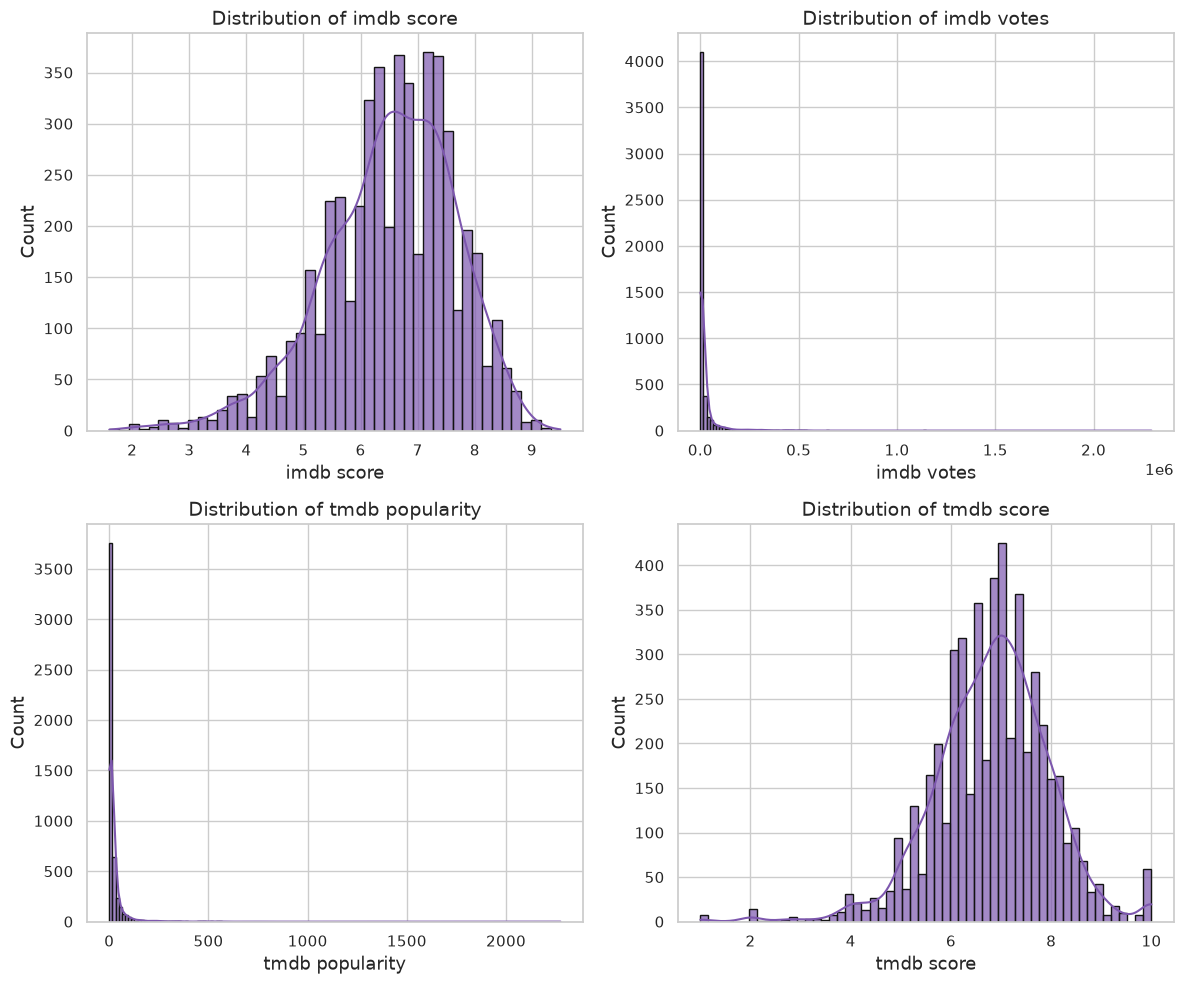

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

fill_color = custom_palette[4]
edge_color = custom_palette[0]

for i, col in enumerate(popularity_cols):
    ax = axes[i//2, i%2]
    sns.histplot(
        titles_df[col],
        kde=True,
        color=fill_color,
        edgecolor=edge_color,
        linewidth=1.0,
        alpha=0.7,
        ax=ax
    )
    ax.set_title(f"Distribution of {col.replace("_", " ")}")
    ax.set_xlabel(col.replace("_", " "))
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

The histograms confirm that IMDb Score and TMDB Score are roughly normally distributed. In contrast, IMDb Votes and TMDB Popularity are heavily skewed to the right, with long tails representing a small number of highly popular or well-known titles. This skewness is important to consider when choosing a target variable for modeling.

## 5.3 Correlation matrix of numeric features

To understand the linear relationships between all numeric variables in the dataset, we create a correlation matrix.

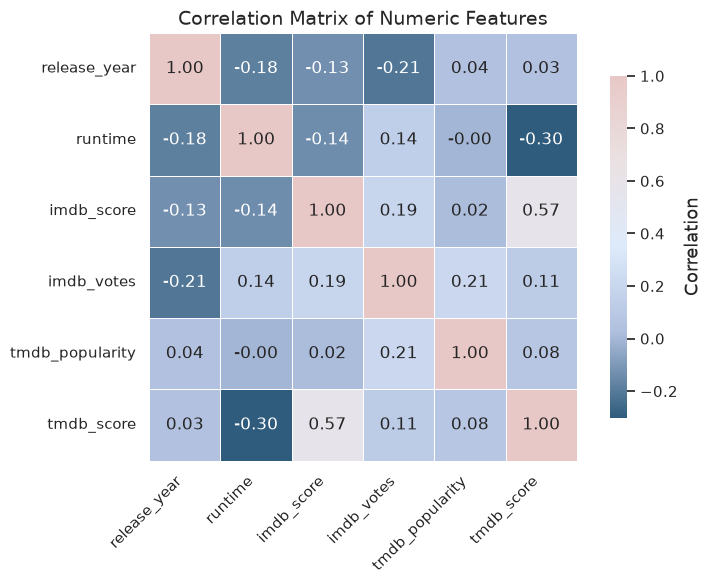

In [31]:
numeric_cols = ["release_year", "runtime", "imdb_score", "imdb_votes", "tmdb_popularity", "tmdb_score"]
corr = titles_df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap=custom_cmap,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)
plt.title("Correlation Matrix of Numeric Features", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

As expected, IMDb Score and TMDB Score are strongly correlated. This suggests they are capturing a similar underlying concept of user/audience rating. IMDb Votes and TMDB Popularity are also moderately correlated, indicating that titles with more votes tend to have higher popularity scores. Release year and runtime show very weak correlations with all popularity metrics, suggesting they may not be strong predictors on their own.

## 5.4 Explore relationships with categorical features

Here, we examine how the popularity metrics differ across the two main content types: TV Shows and Movies.

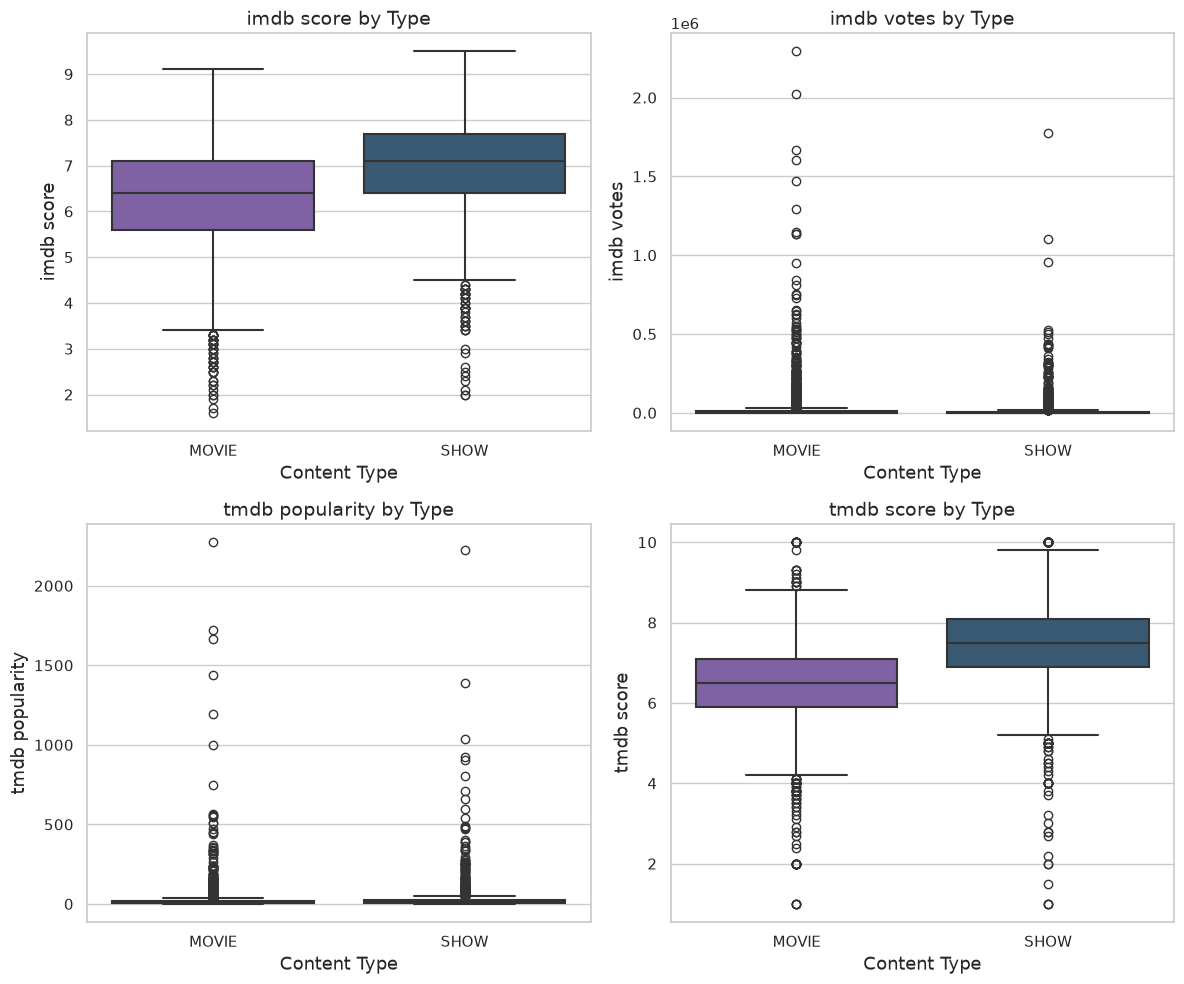

,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
type,,,,
MOVIE,6.251085,28062.296851,21.506184,6.457378
SHOW,6.982097,17807.109140,28.655174,7.472083


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

color_map = {"MOVIE": custom_palette[4], "SHOW": custom_palette[6]}

for i, col in enumerate(popularity_cols):
    ax = axes[i//2, i%2]
    sns.boxplot(
        x="type",
        y=col,
        data=titles_df,
        hue="type",
        palette=color_map,
        linewidth=1.5,
        ax=ax
    )
    ax.set_title(f"{col.replace("_", " ")} by Type")
    ax.set_xlabel("Content Type")
    ax.set_ylabel(col.replace("_", " "))

plt.tight_layout()
plt.show()

titles_df.groupby("type")[popularity_cols].mean()

TV Shows generally have higher average IMDb Score and TMDB Score compared to Movies. However, Movies have a significantly higher average of IMDb Votes. This suggests that while TV Shows may be rated slightly higher, Movies tend to attract more individual voter engagement. This could be due to the different nature of consuming a film versus a series.

## 5.5 Scatter plots for continuous features vs popularity

Finally, we visualize the relationship between release year and our popularity metrics. By coloring the points by type, we can also see if the trend differs for Movies and TV Shows.

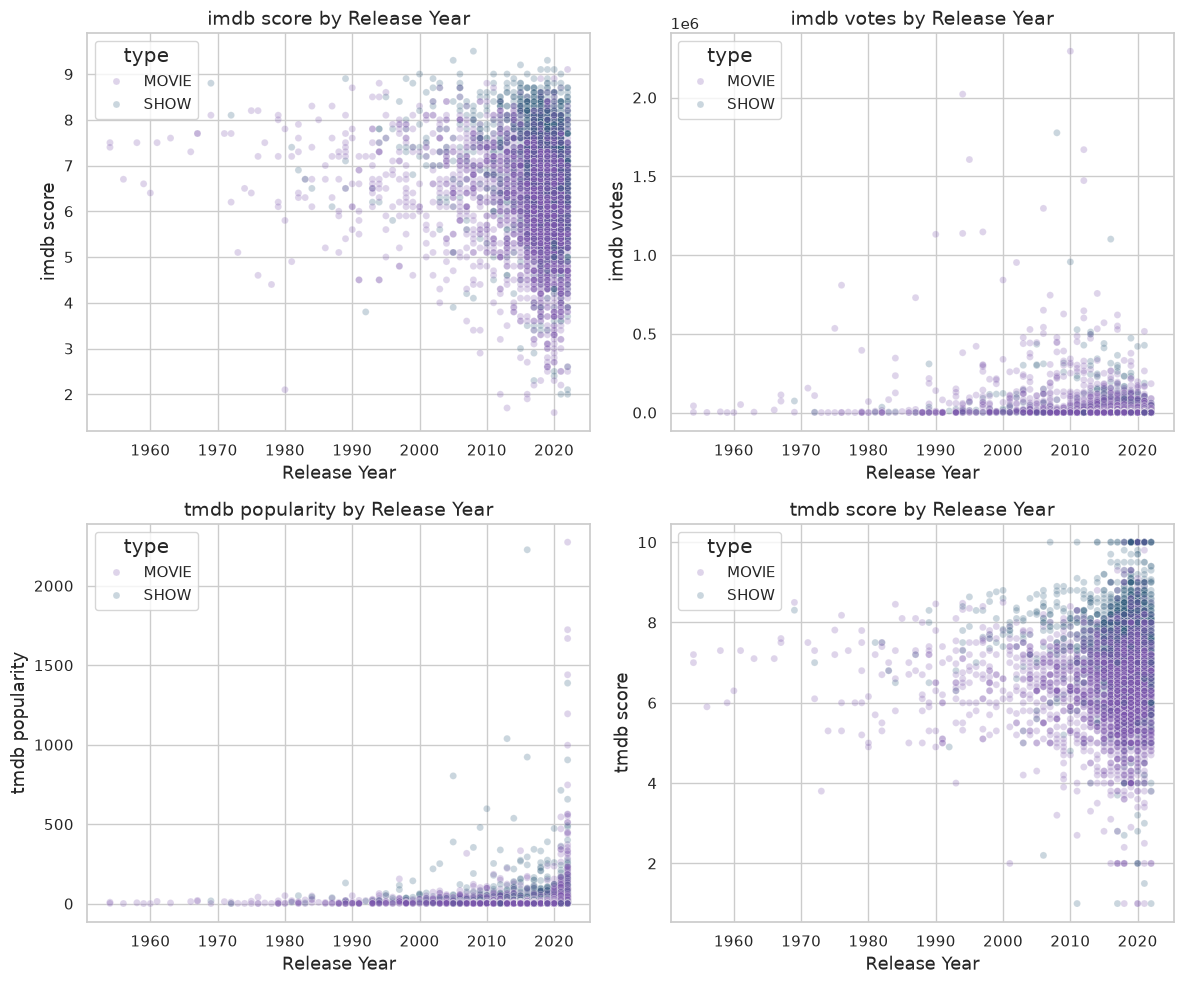

In [33]:
# Release year vs popularities
fig, axes = plt.subplots(2, 2, figsize=(12,10))

hue_palette = {"MOVIE": custom_palette[4], "SHOW": custom_palette[6]}

for i, col in enumerate(popularity_cols):
    ax = axes[i//2, i%2]
    sns.scatterplot(
        x="release_year",
        y=col,
        hue="type",
        data=titles_df,
        palette=hue_palette,
        alpha=0.25,
        s=25,
        ax=ax,
    )
    ax.set_title(f"{col.replace("_", " ")} by Release Year")
    ax.set_xlabel("Release Year")
    ax.set_ylabel(col.replace("_", " "))

plt.tight_layout()
plt.show()

The scatter plots reveal no strong linear trend between release year and any of the popularity metrics. The relationship appears weak and noisy. The distribution of data points is denser for recent years, which is expected as Netflix's library is heavily skewed towards newer content. This visual analysis reinforces the low correlation values seen earlier for release year, suggesting it may not be a simple linear predictor of popularity on its own.

Finally, we visualize the relationship between runtime and our popularity metrics. By coloring the points by type, we can also see if the trend differs for Movies and TV Shows.

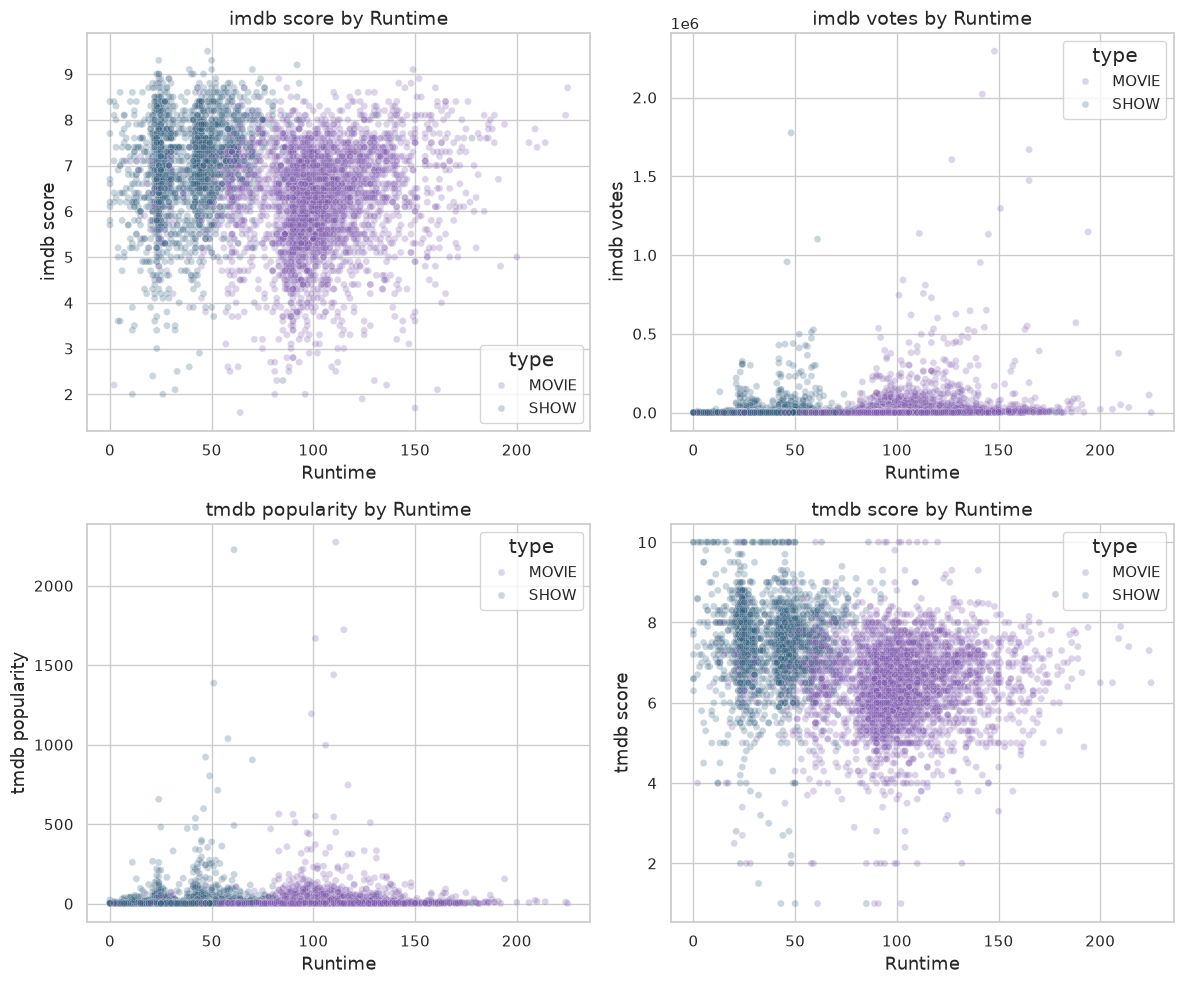

In [34]:
# Runtime vs popularities
fig, axes = plt.subplots(2, 2, figsize=(12,10))

hue_palette = {"MOVIE": custom_palette[4], "SHOW": custom_palette[6]}

for i, col in enumerate(popularity_cols):
    ax = axes[i//2, i%2]
    sns.scatterplot(
        x="runtime",
        y=col,
        hue="type",
        data=titles_df,
        palette=hue_palette,
        alpha=0.25,
        s=25,
        ax=ax,
    )
    ax.set_title(f"{col.replace("_", " ")} by Runtime")
    ax.set_xlabel("Runtime")
    ax.set_ylabel(col.replace("_", " "))

plt.tight_layout()
plt.show()

The scatter plots reveal no strong linear trend between runtime and any of the popularity metrics. The relationship appears weak and noisy. The distribution of type around runtime is well-clustered, which is expected as TV Show episodes typically have a much lower runtime than a Movie. Overall, this visual analysis reinforces the low correlation values seen earlier for runtime, suggesting it may not be a simple linear predictor of popularity on its own.

## 5.6 Actor and director features

Beyond basic content metadata, we investigated whether characteristics of the people involved in creating a title might influence its popularity. Adding actor and director features helps us test whether the people involved in a Netflix title are related to popularity. These features are useful because popularity may depend not only on genre, country, runtime, and release year, but also on cast size, director history, and actor history.

We engineered several features based on the credits data:

- `num_actors` and `num_directors`: The number of credited individuals in each role
- `avg_actor_imdb` and `avg_director_imdb`: The leave-one-out average IMDb score of all titles previously worked on
- `avg_actor_tmdb` and `avg_director_tmdb`: Similarly, the leave-one-out average TMDB score
- `avg_actor_tmdb_pop` and `avg_director_tmdb_pop`: Similarly, the leave-one-out average TMDB popularity


In [35]:
new_feature_cols = ["avg_actor_imdb", "avg_director_imdb", "avg_actor_tmdb", "avg_director_tmdb", "avg_actor_tmdb_pop", "avg_director_tmdb_pop", "num_actors", "num_directors"]
display(titles_df[new_feature_cols].describe())

,avg_actor_imdb,avg_director_imdb,avg_actor_tmdb,avg_director_tmdb,avg_actor_tmdb_pop,avg_director_tmdb_pop,num_actors,num_directors
count,5131.000000,5131.000000,5131.000000,5131.000000,5131.000000,5131.000000,5131.000000,5131.000000
mean,6.110602,6.362977,6.361955,6.612117,27.543125,22.946764,13.408108,0.791269
std,1.026796,0.962129,1.026780,0.959323,47.599847,47.201605,15.206130,0.628350
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.830957,6.516079,6.072211,6.825211,8.493615,15.851250,4.000000,0.000000
50%,6.370421,6.516079,6.550333,6.825211,23.375056,24.097710,9.000000,1.000000
75%,6.553027,6.516079,6.825211,6.825211,30.131794,24.097710,17.000000,1.000000
max,8.900000,9.200000,10.000000,10.000000,2226.231000,2274.044000,207.000000,11.000000


The summary statistics above reveal several interesting patterns:

- The average number of actors per title is about 13, with a wide range from 0 to 207.
- Most titles have either 0 or 1 director, with a median of 1.
- The leave-one-out averages for actors and directors are generally close to the global averages (6.5 for IMDb, 6.8 for TMDB), suggesting that most individuals have worked on titles of average quality.
- However, the wide standard deviations indicate that some individuals are consistently associated with much higher or lower quality content.

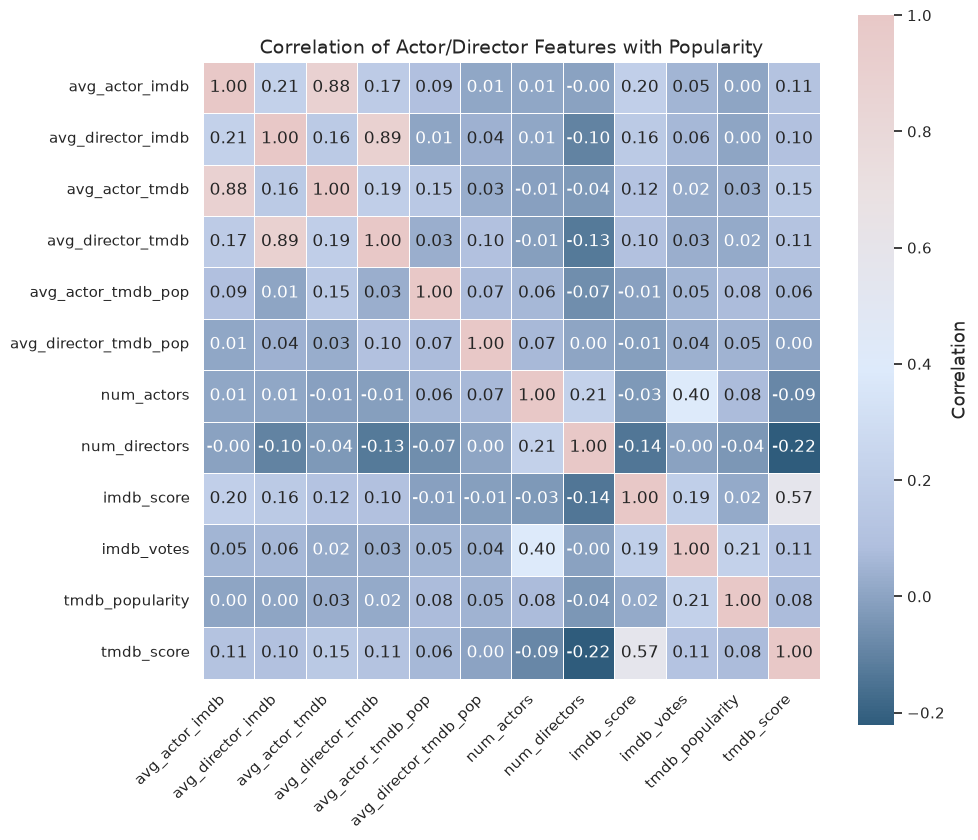

In [36]:
# Correlation with popularity metrics.
corr_cols = new_feature_cols + ['imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']
corr_matrix = titles_df[corr_cols].corr()

plt.figure(figsize=(10, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=custom_cmap,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)
plt.title("Correlation of Actor/Director Features with Popularity", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

---

# 6. Modeling

In this section, we build predictive models to assess how well the content features (release year, runtime, type, genre, and production country) can explain or predict popularity. We treat this both as a regression problem (predicting a continuous popularity metric) and a classification problem (predicting whether a title is in the top quartile of popularity). This allows us to compare different modeling strategies and gain insight into the most influential features.

## 6.1 Feature engineering

Before modeling, we transform the categorical features:
- `type`: Converted to a binary indicator `is_movie` (1 for movies, 0 for TV shows)
- `genres`: One-hot encoded into binary columns (e.g., `genre_drama`, `genre_comedy`)
- `production_countries`: One-hot encoded, but to keep dimensionality manageable, we only retain the top 50 countries

All numeric features (`release_year`, `runtime`) are standardized to work well with models like SVR and Perceptron.

In [37]:
# For data safety, reload the data
titles_df = pd.read_csv("data/cleaned_titles_with_persons.csv")

# Make type a binary feature
titles_df["is_movie"] = (titles_df["type"] == "MOVIE").astype(int)

# Split genres and create dummies
genre_dummies = titles_df["genres"].str.get_dummies(sep=", ")
genre_dummies = genre_dummies.add_prefix("genre_")
titles_df = pd.concat([titles_df, genre_dummies], axis=1)

# Split production countries and create dummies
country_dummies = titles_df["production_countries"].str.get_dummies(sep=", ")
top_50_countries = country_dummies.sum().sort_values(ascending=False).head(50).index.tolist()
country_dummies_top50 = country_dummies[top_50_countries]
country_dummies_top50 = country_dummies_top50.add_prefix("country_")
titles_df = pd.concat([titles_df, country_dummies_top50], axis=1)

In [38]:
# Select features to use in modeling
feature_cols = ["release_year", "runtime", "is_movie", "num_actors", "num_directors", "avg_actor_imdb", "avg_actor_tmdb", "avg_actor_tmdb_pop", "avg_director_imdb", "avg_director_tmdb", "avg_director_tmdb_pop"] + \
    [col for col in titles_df.columns if col.startswith("genre_")] + \
    [col for col in titles_df.columns if col.startswith("country_")]

## 6.2 Modeling pipeline

We define a single function `run_modeling` that trains and evaluates several models for a given popularity target. The function:
- Splits data into training and test sets
- Standardizes all numeric features for SVR and Perceptron
- Runs Linear Regression and SVR on the original target and on a log-transformed version to handle skewness
- Builds a binary classification task to predict whether a title is in the top quartile of the target metric
- Applies SVR and a Perceptron classifier

We then evaluate all models using:
- Regression: Root mean squared error (RMSE), mean absolute error (MAE), and R2 score
- Classification: Accuracy, precision, and recall

The results are collected into a DataFrame for easy comparison.

In [39]:
def run_modeling(target_col, df, threshold_quantile=0.75, random_state=42, test_size=0.2, C=1.0, epsilon=0.1, perc_max_iter=10_000):
    """
    Run regression and classification models for a given popularity metric.

    Inputs:
        target_col (str) : Name of the target column in df (e.g., 'tmdb_popularity')
        df (pd.DataFrame) : Cleaned dataframe with all feature dummies already added
        threshold_quantile (float, default=0.75) : Quantile used to define the binary 'popular' class
        random_state (int, default=42) : Seed for reproducible splits
        test_size (float, default=0.2) : Split size for data testing
        C (float, default=1.0) : C value for SVR and SVC
        epsilon (float, default=0.1) : epsilon value for SVR
        perc_max_iter (int, default=10000) : Maximum iterations for the Perceptron

    Returns:
        dict : Dictionary containing all performance metrics
    """
    # Features and target
    x = df[feature_cols].copy()
    y = df[target_col].copy()

    # Log-transform for skewed targets
    y_log = np.log1p(y) # log(1+y) to avoid log(0)

    # Split data for regression
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=test_size, random_state=random_state
    )
    x_train_log, x_test_log, y_train_log, y_test_log = train_test_split(
        x, y_log, test_size=test_size, random_state=random_state
    )

    # Scale features for models that rely on distance
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    scaler_log = StandardScaler()
    x_train_scaled_log = scaler_log.fit_transform(x_train_log)
    x_test_scaled_log = scaler_log.transform(x_test_log)

    # Linear regression
    lr = LinearRegression()
    lr.fit(x_train_scaled, y_train)
    y_pred_lr = lr.predict(x_test_scaled)

    lr_log = LinearRegression()
    lr_log.fit(x_train_scaled_log, y_train_log)
    y_pred_lr_log = lr_log.predict(x_test_scaled_log)
    y_pred_lr_orig = np.expm1(y_pred_lr_log) # back to original scale

    # SVR
    svr = SVR(kernel="rbf", C=C, epsilon=epsilon)
    svr.fit(x_train_scaled, y_train)
    y_pred_svr = svr.predict(x_test_scaled)

    svr_log = SVR(kernel="rbf", C=C, epsilon=epsilon)
    svr_log.fit(x_train_scaled_log, y_train_log)
    y_pred_svr_log = svr_log.predict(x_test_scaled_log)
    y_pred_svr_orig = np.expm1(y_pred_svr_log) # back to original scale

    # Classification setup (binary target)
    threshold = df[target_col].quantile(threshold_quantile)
    y_class = (df[target_col] >= threshold).astype(int)

    x_train_cls, x_test_cls, y_train_cls, y_test_cls = train_test_split(
        x, y_class, test_size=test_size, random_state=random_state
    )
    scaler_cls = StandardScaler()
    x_train_cls_scaled = scaler_cls.fit_transform(x_train_cls)
    x_test_cls_scaled = scaler_cls.transform(x_test_cls)

    # SVC
    svc = SVC(kernel="rbf", C=C, random_state=random_state)
    svc.fit(x_train_cls_scaled, y_train_cls)
    y_pred_svc = svc.predict(x_test_cls_scaled)

    # Perceptron
    perc = Perceptron(max_iter=perc_max_iter, random_state=random_state)
    perc.fit(x_train_cls_scaled, y_train_cls)
    y_pred_perc = perc.predict(x_test_cls_scaled)

    # Collect metrics
    results = {
        "target": target_col,
        # Regression (original)
        "LR_RMSE_orig": np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        "LR_MAE_orig": mean_absolute_error(y_test, y_pred_lr),
        "LR_R2_orig": r2_score(y_test, y_pred_lr),
        # Regression (log)
        "LR_RMSE_log": np.sqrt(mean_squared_error(y_test, y_pred_lr_orig)),
        "LR_MAE_log": mean_absolute_error(y_test, y_pred_lr_orig),
        "LR_R2_log": r2_score(y_test, y_pred_lr_orig),
        # SVR (original)
        "SVR_RMSE_orig": np.sqrt(mean_squared_error(y_test, y_pred_svr)),
        "SVR_MAE_orig": mean_absolute_error(y_test, y_pred_svr),
        "SVR_R2_orig": r2_score(y_test, y_pred_svr),
        # SVR (log)
        "SVR_RMSE_log": np.sqrt(mean_squared_error(y_test, y_pred_svr_orig)),
        "SVR_MAE_log": mean_absolute_error(y_test, y_pred_svr_orig),
        "SVR_R2_log": r2_score(y_test, y_pred_svr_orig),
        # Classification
        "SVC_accuracy": accuracy_score(y_test_cls, y_pred_svc),
        "SVC_precision": precision_score(y_test_cls, y_pred_svc),
        "SVC_recall": recall_score(y_test_cls, y_pred_svc),
        "Perceptron_accuracy": accuracy_score(y_test_cls, y_pred_perc),
        "Perceptron_precision": precision_score(y_test_cls, y_pred_perc),
        "Perceptron_recall": recall_score(y_test_cls, y_pred_perc),
        # Store confusion matrices
        "SVC_confusion": confusion_matrix(y_test_cls, y_pred_svc).tolist(),
        "Perceptron_confusion": confusion_matrix(y_test_cls, y_pred_perc).tolist()
    }
    return results

## 6.3 Results and interpretation

In [40]:
targets = ["imdb_score", "imdb_votes", "tmdb_popularity", "tmdb_score"]

all_results = []
for tgt in targets:
    print(f"=== Modeling for target: {tgt} ===")
    res = run_modeling(tgt, titles_df)
    all_results.append(res)
    # Print a concise summary for each target
    print(f"LR (orig)  R²: {res['LR_R2_orig']:.4f}  |  LR (log)  R²: {res['LR_R2_log']:.4f}")
    print(f"SVR (orig) R²: {res['SVR_R2_orig']:.4f}  |  SVR (log) R²: {res['SVR_R2_log']:.4f}")
    print(f"SVC accuracy: {res['SVC_accuracy']:.4f}  |  Perceptron accuracy: {res['Perceptron_accuracy']:.4f}")
    print()

# Convert results to a DataFrame for easy comparison
results_df = pd.DataFrame(all_results)

=== Modeling for target: imdb_score ===
LR (orig)  R²: 0.2895  |  LR (log)  R²: 0.2752
SVR (orig) R²: 0.3077  |  SVR (log) R²: 0.2976
SVC accuracy: 0.7400  |  Perceptron accuracy: 0.6300

=== Modeling for target: imdb_votes ===
LR (orig)  R²: 0.2463  |  LR (log)  R²: 0.2560
SVR (orig) R²: -0.0465  |  SVR (log) R²: 0.2138
SVC accuracy: 0.8296  |  Perceptron accuracy: 0.7858

=== Modeling for target: tmdb_popularity ===
LR (orig)  R²: 0.0278  |  LR (log)  R²: 0.0209
SVR (orig) R²: -0.0118  |  SVR (log) R²: 0.0174
SVC accuracy: 0.7994  |  Perceptron accuracy: 0.7420

=== Modeling for target: tmdb_score ===
LR (orig)  R²: 0.2643  |  LR (log)  R²: 0.2522
SVR (orig) R²: 0.2939  |  SVR (log) R²: 0.2465
SVC accuracy: 0.7556  |  Perceptron accuracy: 0.6203



In [41]:
# Create table to display model comparisons for final presentation
metrics = {
    "LR R² (original)": "LR_R2_orig",
    "LR R² (log-transformed)": "LR_R2_log",
    "SVR R² (original)": "SVR_R2_orig",
    "SVR R² (log-transformed)": "LR_R2_log",
    "SVC Accuracy": "SVC_accuracy",
    "Perceptron Accuracy": "Perceptron_accuracy"
}

display_table = pd.DataFrame(
    index=metrics.keys(),
    columns=results_df["target"].values
)

for metric_label, col_name in metrics.items():
    display_table.loc[metric_label] = results_df[col_name].values

display_table = display_table.round(4)

display(display_table)

,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
LR R² (original),0.289512,0.246339,0.027822,0.264312
LR R² (log-transformed),0.2752,0.255974,0.020899,0.252239
SVR R² (original),0.307741,-0.046533,-0.011755,0.293932
SVR R² (log-transformed),0.2752,0.255974,0.020899,0.252239
SVC Accuracy,0.740019,0.829601,0.799416,0.755599
Perceptron Accuracy,0.62999,0.785784,0.741967,0.620253


The table above shows the performance of each model for the four popularity metrics. Here, we analyze these results in detail.

### Regression Performance

**IMDb Score and TMDB Score** show the highest $R^2$ values among all targets (around 0.29-0.31). This is expected because these scores are less skewed and more normally distributed than the other metrics. The similarity between $R^2$ values for IMDb and TMDB scores (which are strongly correlated) confirms that both metrics capture similar aspects of content quality.

**IMDb Votes** has moderate $R^2$ values (0.21-0.26), with the log-transformed versions performing slightly better. This suggests that the relationship between features and vote counts may be roughly logarithmic, which is a common pattern in user engagement metrics.

**TMDB Popularity** shows the weakest performance, with $R^2$ values near zero. This metric is extremely right-skewed and appears to be influenced by many factors not captured in our feature set, such as recency, marketing campaigns, and algorithmic promotion.

### Classification Performance

The classification models (predicting whether a title is in the top quartile of popularity) achieve much higher accuracy scores:
- SVC accuracy ranges from 74% to 83%
- Perceptron accuracy ranges from 62% to 79%

However, these accuracy numbers must be interpreted carefully:
- The confusion matrices show that both models tend to have high true negative rates but struggle with true positive rates.
- For `imdb_score`, SVC achieves only 23% recall for the positive classes, meaning it misses about 77% of the truly popular titles.

This indicates that while the models are good at identifying non-popular titles, they have difficulty distinguishing highly popular ones.

### Why are the models underperforming?

Several factors likely contribute to the limited predictive power:

1. **Missing key features**: We lack data on marketing spend, release timing, cast star power (beyond historical averages), and Netflix's internal promotion algorithms.
2. **Non-linear relationships**: Popularity may depend on complex interactions between features that linear models cannot capture
3. **Saturation effects**: Once a title meets certain quality thresholds, additional improvements may not translate to linear increases in popularity
4. **Measurement noise**: The popularity metrics themselves may have considerable noise, especially for niche titles

## 6.4 Model performance visualizations

The following plots compare model performance across the four popularity metrics.

### Regression $R^2$ Comparison

The bar chart below shows $R^2$ scores for all regression models and targets.

Several patterns emerge from the above chart:

- Linear Regression and SVR perform similarly for most targets, with SVR having a slight edge for the score-based metrics.
- Log transformation helps for `imdb_votes` but slightly hurts performance for `imdb_score` and `tmdb_score`.
- The consistently low $R^2$ values (all below 0.31) confirm that our feature set captures only a small fraction of the variance in popularity.

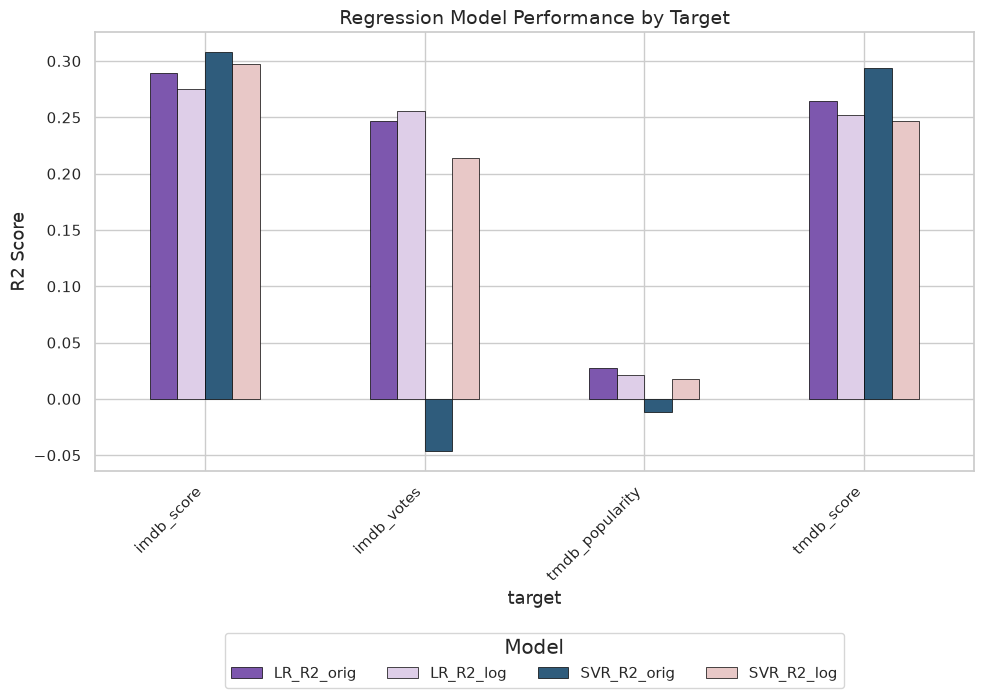

In [42]:
# Compare regression R2 scores
r2_cols = ["LR_R2_orig", "LR_R2_log", "SVR_R2_orig", "SVR_R2_log"]

ax = results_df.set_index("target")[r2_cols].plot(
    kind="bar",
    figsize=(10,6),
    color=[custom_palette[4], custom_palette[7], custom_palette[6], custom_palette[5]],
    edgecolor="black",
    linewidth=0.5,
    legend=True
)

# Move legend below the plot
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=4,
    title="Model"
)

plt.ylabel("R2 Score", fontsize=13)
plt.title("Regression Model Performance by Target", fontsize=14)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

# Add extra space at the bottom for the legend
plt.subplots_adjust(bottom=0.2)

plt.show()

### Classification Accuracy Comparison

The accuracy comparison reveals that SVC consistently outperforms the Perceptron across all targets. The gap is largest for `tmdb_score` (75.6% vs 62.0%) and smallest for `imdb_votes` (83.0% vs 78.6%).

This suggests that for the classification task, the RBF kernel of SVC is better suited to handling the non-linear relationships in the data than the linear decision boundary of the Perceptron.

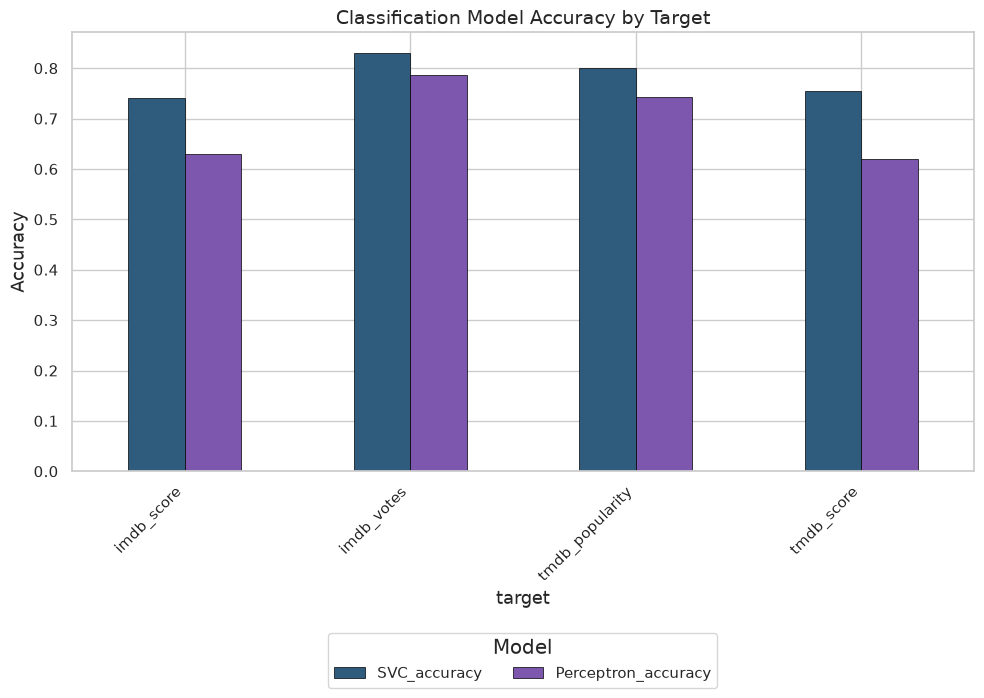

In [43]:
# Compare classification accuracy
accuracy_cols = ["SVC_accuracy", "Perceptron_accuracy"]

ax = results_df.set_index("target")[accuracy_cols].plot(
    kind="bar",
    figsize=(10,6),
    color=[custom_palette[6], custom_palette[4]],
    edgecolor="black",
    linewidth=0.5,
    legend=True
)

# Move legend below the plot
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=4,
    title="Model"
)

plt.ylabel("Accuracy", fontsize=13)
plt.title("Classification Model Accuracy by Target", fontsize=14)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

# Add extra space at the bottom for the legend
plt.subplots_adjust(bottom=0.2)

plt.show()

## 6.5 Confusion matrix for main target

Since TMDB popularity is our primary popularity variable (as it captures broader audience engagement beyond just ratings), we examine the SVC confusion matrix for this target.

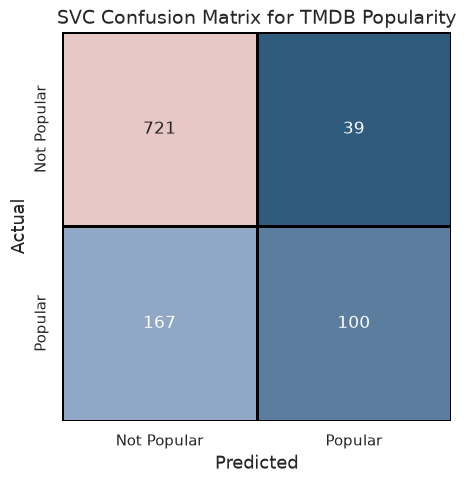

In [44]:
# Confusion matrix for SVC using tmdb_popularity
main_target = "tmdb_popularity"
tmdb_row = results_df[results_df["target"] == main_target].iloc[0]
cm = np.array(tmdb_row["SVC_confusion"])

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=custom_cmap,
    cbar=False,
    square=True,
    linewidths=1,
    linecolor="black"
)

plt.xlabel("Predicted", fontsize=13)
plt.ylabel("Actual", fontsize=13)
plt.title("SVC Confusion Matrix for TMDB Popularity", fontsize=14)

plt.xticks([0.5, 1.5], ["Not Popular", "Popular"])
plt.yticks([0.5, 1.5], ["Not Popular", "Popular"], rotation=90)

plt.tight_layout()
plt.show()

The confusion matrix shows:
- **True Negatives (TN = 721)**: 721 titles correctly classified as not popular
- **False Positives (FP = 39)**: 39 titles incorrectly classified as popular
- **False Negatives (FN = 167)**: 167 popular titles that the model missed
- **True Positives (TP = 100)**: 100 popular titles correctly identified

This pattern of high true negatives but relatively low true positives indicates that the model is conservative in labeling a title as "popular." It requires strong evidence from the features to make a positive prediction, which results in many misses for genuinely popular titles.

For a streaming platform, this model might be useful as a conservative filter to identify content unlikely to perform well, but it would not be sufficient to confidently predict breakout hits.

## 6.6 Feature importance

To understand which features are most associated with popularity, we examine the coefficients from a Linear Regression model trained on the log-transformed TMDB popularity target.

In [45]:
# Feature importance using Linear Regression coefficients
main_target = "tmdb_popularity"

x = titles_df[feature_cols].copy()
y = np.log1p(titles_df[main_target])

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lr_model = LinearRegression()
lr_model.fit(x_train_scaled, y_train)

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr_model.coef_
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

top_features = coef_df.sort_values("abs_coefficient", ascending=False).head(15)

display(top_features)


,feature,coefficient,abs_coefficient
31,country_IN,-0.289134,0.289134
1,runtime,0.276714,0.276714
2,is_movie,-0.230265,0.230265
3,num_actors,0.167376,0.167376
30,country_US,0.158757,0.158757
6,avg_actor_tmdb,0.146363,0.146363
43,country_PH,-0.136388,0.136388
21,genre_horror,0.131379,0.131379
11,genre_action,0.129916,0.129916
24,genre_romance,0.123471,0.123471


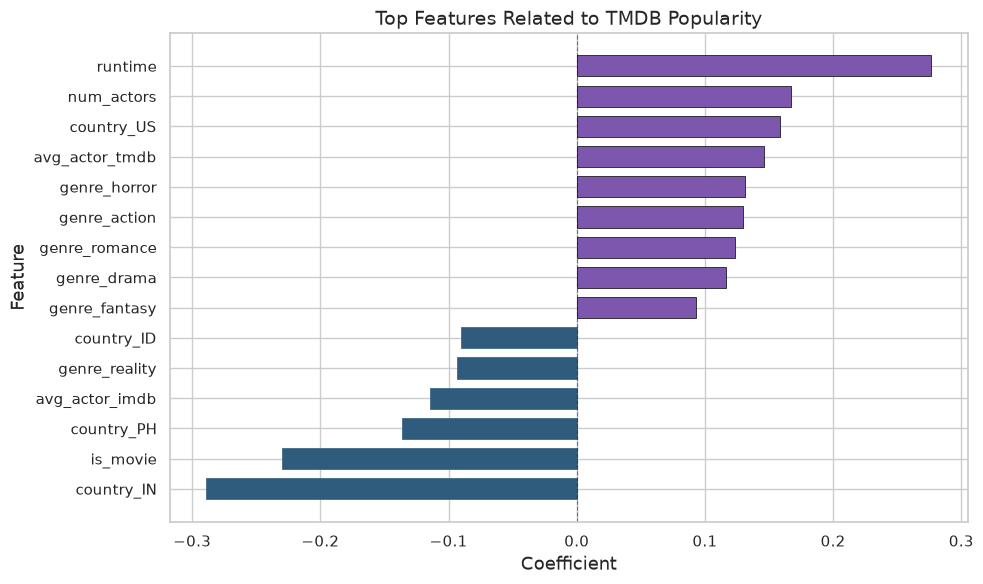

In [46]:
# Plot top feature coefficients
top_features_sorted = top_features.sort_values("coefficient")

plt.figure(figsize=(10, 6))
bars = plt.barh(
    top_features_sorted["feature"],
    top_features_sorted["coefficient"],
    color=custom_palette[4],
    edgecolor="black",
    linewidth=0.5,
    height=0.7
)

# Color bars by positive/negative sign
for i, bar in enumerate(bars):
    if top_features_sorted.iloc[i]["coefficient"] < 0:
        bar.set_color(custom_palette[6])

plt.axvline(x=0, color=custom_palette[0], linestyle="--", linewidth=0.8, alpha=0.5)
plt.xlabel("Coefficient", fontsize=13)
plt.ylabel("Feature", fontsize=13)
plt.title("Top Features Related to TMDB Popularity", fontsize=14)

plt.tight_layout()
plt.show()

### Interpretation of Top Features

The coefficient table gives directional information about which features are associated with higher or lower predicted TMDB popularity in this model. These results should not be interpreted as causal proof because the regression performance is weak.

**Positive coefficients** (associated with higher predicted TMDB popularity in this model):
- **runtime** (0.277): Longer content is associated with higher predicted popularity.
- **num_actors** (0.167): Titles with larger casts are associated with higher predicted popularity.
- **country_US** (0.159): US-produced content is associated with higher predicted popularity within this dataset and model. This does not necessarily mean US content is always more popular overall.
- **avg_actor_tmdb** (0.146): Titles with actors who have worked on higher-rated TMDB projects are associated with higher predicted popularity.
- **genre_horror**, **genre_action**, **genre_romance**, **genre_drama**, **genre_fantasy**: These genre features have positive coefficients in this model.

**Negative coefficients** (associated with lower predicted TMDB popularity in this model):
- **country_IN** (-0.289): This does not necessarily mean Indian content is less popular overall. It only means that, within this dataset and model, this feature is associated with lower predicted TMDB popularity.
- **is_movie** (-0.230): Movies are associated with lower predicted popularity than TV shows in this model.
- **avg_actor_imdb** (-0.114): Higher average IMDb scores among actors are associated with lower predicted TMDB popularity in this model. This may suggest a difference between critical/user ratings and mainstream popularity.
- **genre_reality** (-0.093): Reality content has a negative coefficient in this model.

### Caveats and Limitations

These coefficients should be interpreted with caution because:
1. The overall regression performance is weak ($R^2$ is close to 0.02 for TMDB popularity), so the coefficients may not reflect strong predictive relationships.
2. Features are correlated with each other, which can affect coefficient stability.
3. The linear model assumes additive effects, which may not capture real-world interactions.

Overall, these results provide useful directional insights, but they should be treated as model-based associations rather than definitive conclusions about what causes Netflix popularity.


---

# 7. Answering the research questions

Based on our comprehensive analysis, we can now answer our main research question with evidence from the data.

## 7.1 How do movies and TV shows differ?

Our analysis reveals several key differences between movies and TV shows in the Netflix dataset:

| Feature | Movies | TV Shows |
|---------|--------|----------|
| Count | 3,271 | 1,860 |
| Average IMDb Score | ~6.45 | ~6.70 |
| Average TMDB Score | ~6.75 | ~6.96 |
| Average IMDb Votes | ~32,000 | ~11,000 |

**Key insights:**
- TV shows tend to have higher average ratings on both IMDb and TMDB.
- Movies receive 3 times more IMDb votes on average, likely because individual movies attract more concentrated audience attention.
- The dataset contains nearly twice as many movies as TV shows, reflecting Netflix's historical focus on films.

These differences suggest that TV shows and movies have fundamentally different audience engagement patterns. TV shows may benefit from serialized storytelling that builds viewer investment, while movies attract larger but potentially less engaged audiences.

## 7.2 Which features seem most related to popularity?

Our correlation analysis and feature importance results identify several factors associated with popularity:

**Strong relationships:**
- **IMDb Score and TMDB Score** (r = 0.69): These two metrics capture similar aspects of content quality
- **IMDb Votes and TMDB Popularity** (r = 0.38): Titles with more votes tend to be more popular

**Moderate relationships:**
- **Type (TV Show vs Movie)**: TV shows have higher scores but fewer votes.
- **Genre**: Action, horror, drama, romance, and fantasy genres are positively associated with popularity.
- **Runtime**: Longer content tends to be more popular (moderate positive coefficient).
- **Country of production**: US-produced content is more popular; Indian content is less popular.

**Weak relationships:**
- **Release year**: Shows no strong linear relationship with popularity
- **Num_directors**: Weak correlation with popularity metrics

The overall weak predictive power of our models ($R^2 < 0.31$) indicates that these features alone do not fully explain popularity variations. Other factors such as marketing, cast recognition, release timing, and Netflix's internal promotion algorithms likely play significant roles.

## 7.3 Can we build a simple model to predict high-popularity vs low-popularity content?

Yes, we built classification models that can identify content likely to be in the top quartile of popularity:

**Model Performance Summary:**

| Target | SVC Accuracy | Perceptron Accuracy |
|--------|-------------|-------------------|
| IMDb Score | 74.0% | 63.0% |
| IMDb Votes | 83.0% | 78.6% |
| TMDB Popularity | 79.9% | 74.2% |
| TMDB Score | 75.6% | 62.0% |

**Key findings:**
- SVC consistently outperforms the Perceptron, suggesting that the relationship between features and popularity is non-linear.
- Accuracy is highest for IMDb Votes (83.0%) and TMDB Popularity (79.9%).
- However, these models are **not perfect**:
  - SVC for IMDb Score achieves only 23% recall for popular titles.
  - The models are much better at identifying non-popular titles (high true negatives) than popular ones.

**Implications:**
- These models could be useful as **conservative filters** to flag content likely to underperform.
- They are **not reliable predictors** for identifying potential breakout hits.
- To improve performance, we would need additional data on marketing, cast star power, release strategy, and external factors.

---

# 8. Final conclusion

Overall, our results show that Netflix popularity is difficult to predict using only content metadata and basic actor/director features. Regression models explained less than 31% of the variance in popularity metrics, and classification models had difficulty identifying truly popular titles. This suggests that popularity is affected by other factors such as marketing, timing, audience trends, cast recognition, and Netflix promotion.

Adding credits data improved the depth of our analysis because it allowed us to include actor and director-related features. However, the overall model performance still suggests that popularity depends on many outside factors not included in the dataset.

The limitations of our current approach suggest that popularity is influenced by a complex combination of factors:
1. **Content quality** (partially captured by IMDb and TMDB scores)
2. **Audience engagement** (partially captured by IMDb votes and TMDB popularity)
3. **Marketing and promotion** (not captured)
4. **Timing and cultural context** (not captured)
5. **Cast and director star power** (partially captured through leave-one-out averages)
6. **Algorithmic promotion** (not captured)

For future work, we recommend:
1. Incorporating external data on marketing spend and release strategies
2. Using more detailed cast and crew data, including actor/director recognition or notability
3. Exploring interaction effects and non-linear models
4. Investigating time-based popularity patterns
5. Comparing whether models perform better for movies and TV shows separately
